# Regression Task: Predicting Stress Level

This notebook focuses on a supervised regression problem. The objective is to predict the `Stress_Level` variable using demographic, lifestyle, digital behavior, and mental health-related features.

The dataset contains 2,000 records and 18 columns. It includes variables such as age, gender, occupation, screen time, social media usage, night usage, sleep hours, work/study hours, physical activity, social interaction score, caffeine intake, smoking, alcohol consumption, depression, anxiety, and burnout.

The target variable for this regression task is `Stress_Level`.

The goal is to compare several regression algorithms, evaluate their performance, tune the best models, analyze learning curves, and interpret predictions using SHAP.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "mental_health.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [3]:
print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (2000, 18)
['Person_ID', 'Age', 'Gender', 'Occupation', 'Daily_Screen_Time', 'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours', 'Physical_Activity', 'Social_Interaction_Score', 'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety', 'Burnout']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   Occupation                2000 non-null   object 
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   object 
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol 

In [5]:
df.isnull().sum()

Person_ID                   0
Age                         0
Gender                      0
Occupation                  0
Daily_Screen_Time           0
Social_Media_Usage          0
Night_Usage                 0
Sleep_Hours                 0
Stress_Level                0
Work_Study_Hours            0
Physical_Activity           0
Social_Interaction_Score    0
Caffeine_Intake             0
Smoking                     0
Alcohol                     0
Depression                  0
Anxiety                     0
Burnout                     0
dtype: int64

In [6]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,0.489500,6.00765,5.409500,7.005650,5.488000,2.029500,0.492000,0.513000,0.499000,0.505500,0.515500
std,577.494589,12.614195,2.882415,2.011725,0.500015,1.70631,2.885129,2.846442,2.885484,1.432709,0.500061,0.499956,0.500124,0.500095,0.499885
min,1.000000,16.000000,2.000000,1.000000,0.000000,3.00000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,0.000000,4.60000,3.000000,4.500000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1000.500000,38.000000,6.800000,4.400000,0.000000,6.00000,5.000000,7.100000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000
75%,1500.250000,49.000000,9.400000,6.200000,1.000000,7.50000,8.000000,9.400000,8.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2000.000000,59.000000,12.000000,8.000000,1.000000,9.00000,10.000000,12.000000,10.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Initial Dataset Inspection

The dataset contains 2,000 records and 18 columns. There are no missing values, so no imputation is required.

The dataset contains both numerical and categorical variables. The numerical variables include age, daily screen time, social media usage, night usage, sleep hours, stress level, work/study hours, social interaction score, caffeine intake, smoking, alcohol consumption, depression, anxiety, and burnout. The categorical variables include gender, occupation, and physical activity.

For this regression task, the target variable is `Stress_Level`.

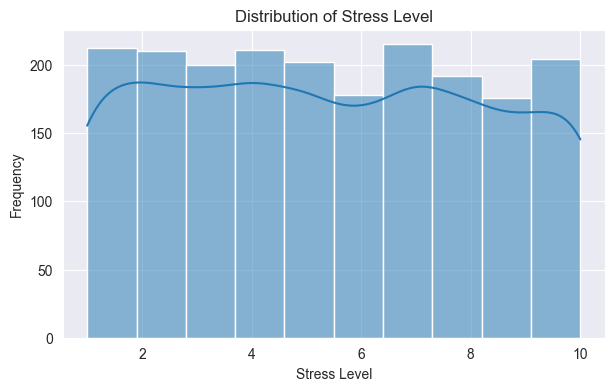

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df["Stress_Level"], bins=10, kde=True)
plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Frequency")
plt.show()

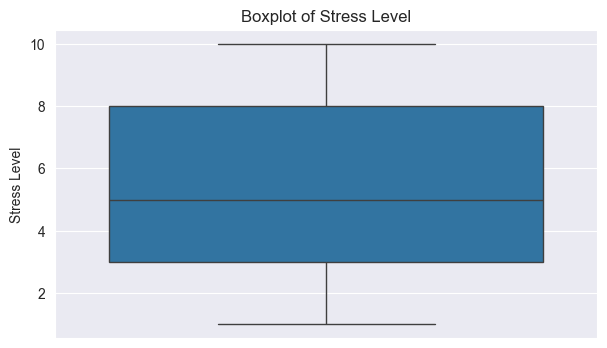

In [8]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, y="Stress_Level")
plt.title("Boxplot of Stress Level")
plt.ylabel("Stress Level")
plt.show()

In [9]:
df["Stress_Level"].describe()

count    2000.000000
mean        5.409500
std         2.885129
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: Stress_Level, dtype: float64

In [10]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_columns.remove("Person_ID")

correlations_with_stress = df[numeric_columns].corr()["Stress_Level"].sort_values(ascending=False)

correlations_with_stress

Stress_Level                1.000000
Anxiety                     0.278755
Depression                  0.225461
Burnout                     0.208394
Alcohol                     0.027000
Smoking                     0.023596
Social_Interaction_Score    0.005909
Night_Usage                 0.005583
Social_Media_Usage         -0.003526
Daily_Screen_Time          -0.007215
Caffeine_Intake            -0.011395
Age                        -0.021641
Work_Study_Hours           -0.022692
Sleep_Hours                -0.028459
Name: Stress_Level, dtype: float64

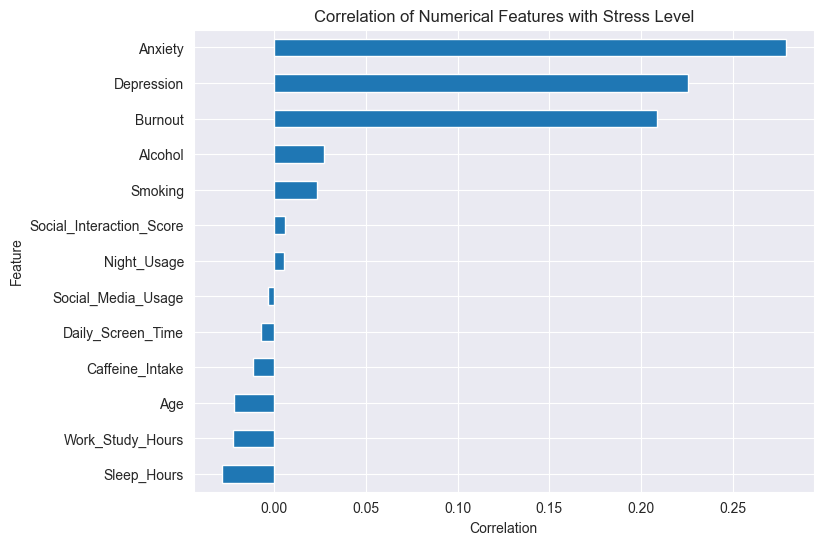

In [11]:
plt.figure(figsize=(8, 6))
correlations_with_stress.drop("Stress_Level").sort_values().plot(kind="barh")
plt.title("Correlation of Numerical Features with Stress Level")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

## Regression EDA Interpretation

The target variable `Stress_Level` ranges from 1 to 10, with an average value of approximately 5.41. The distribution is relatively spread across the full scale, which makes it suitable for a regression task.

The correlation analysis shows that `Anxiety` and `Depression` have the strongest positive relationships with `Stress_Level`. This suggests that higher anxiety and depression indicators tend to be associated with higher stress levels.

Other variables, such as sleep hours, work/study hours, age, caffeine intake, and daily screen time, show weaker individual correlations with stress level. However, they may still contribute to the prediction when combined by machine learning models.

In [12]:
X = df.drop(columns=["Person_ID", "Stress_Level", "Burnout"])
y = df["Stress_Level"]

X.head()

,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety
0,54,Male,Student,10.2,7.5,0,6.5,5.8,Low,6,2,0,1,1,1
1,44,Male,Student,6.8,4.5,0,5.1,7.9,High,2,1,1,0,0,0
2,30,Male,Employed,5.5,6.9,0,3.5,9.4,Low,2,0,1,1,1,0
3,58,Male,Employed,5.6,4.1,0,9.0,2.0,High,10,0,0,1,0,0
4,23,Female,Employed,10.1,6.0,1,3.8,4.6,Low,4,4,0,1,1,1


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1500, 15)
Test shape: (500, 15)


In [14]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age', 'Daily_Screen_Time', 'Social_Media_Usage', 'Night_Usage', 'Sleep_Hours', 'Work_Study_Hours', 'Social_Interaction_Score', 'Caffeine_Intake', 'Smoking', 'Alcohol', 'Depression', 'Anxiety']
Categorical features: ['Gender', 'Occupation', 'Physical_Activity']


In [15]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

In [17]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbor Regressor": KNeighborsRegressor(),
    "Gaussian Process Regressor": GaussianProcessRegressor(alpha=1e-2, normalize_y=True, random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42),
    "Explainable Boosting Regressor": ExplainableBoostingRegressor(random_state=42)
}

In [18]:
regression_results = []
trained_regression_models = {}

for model_name, model in regression_models.items():
    print(f"Training {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    regression_results.append({
        "Model": model_name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_regression_models[model_name] = pipeline

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values(by="RMSE", ascending=True)

regression_results_df

Training Linear Regression...
Training Decision Tree Regressor...
Training Random Forest Regressor...
Training Support Vector Regressor...
Training K-Nearest Neighbor Regressor...
Training Gaussian Process Regressor...
Training XGBoost Regressor...
Training CatBoost Regressor...
Training Explainable Boosting Regressor...


,Model,MSE,MAE,RMSE,R2
0,Linear Regression,7.601472,2.332406,2.757077,0.105404
8,Explainable Boosting Regressor,7.673548,2.353202,2.770117,0.096922
2,Random Forest Regressor,7.929435,2.387340,2.815925,0.066807
5,Gaussian Process Regressor,8.098141,2.456335,2.845723,0.046952
7,CatBoost Regressor,8.158401,2.414483,2.856291,0.039861
3,Support Vector Regressor,8.194500,2.384010,2.862604,0.035612
4,K-Nearest Neighbor Regressor,8.426400,2.405600,2.902826,0.008320
6,XGBoost Regressor,9.614501,2.579025,3.100726,-0.131504
1,Decision Tree Regressor,15.906000,3.242000,3.988233,-0.871933


In [19]:
top_5_regression_models = regression_results_df.head(5)
top_5_regression_models

,Model,MSE,MAE,RMSE,R2
0,Linear Regression,7.601472,2.332406,2.757077,0.105404
8,Explainable Boosting Regressor,7.673548,2.353202,2.770117,0.096922
2,Random Forest Regressor,7.929435,2.387340,2.815925,0.066807
5,Gaussian Process Regressor,8.098141,2.456335,2.845723,0.046952
7,CatBoost Regressor,8.158401,2.414483,2.856291,0.039861


In [20]:
REGRESSION_BASE_METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "regression_base_models_results.csv"

regression_results_df.to_csv(REGRESSION_BASE_METRICS_PATH, index=False)

print("Saved to:", REGRESSION_BASE_METRICS_PATH)

Saved to: D:\faculta\an3\sem2\ProiectMl\outputs\metrics\regression_base_models_results.csv


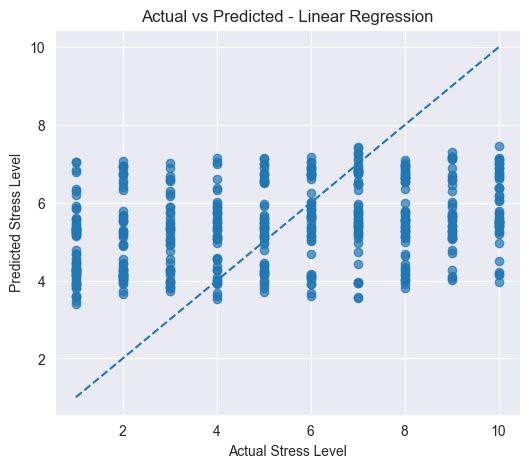

In [21]:
best_regression_model_name = regression_results_df.iloc[0]["Model"]
best_regression_model = trained_regression_models[best_regression_model_name]

y_pred_best_regression = best_regression_model.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_best_regression, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title(f"Actual vs Predicted - {best_regression_model_name}")
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.show()

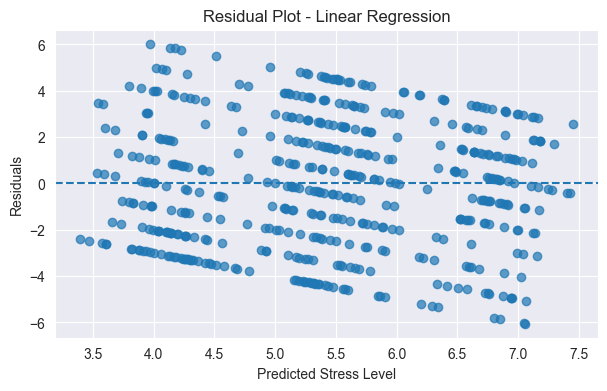

In [22]:
residuals = y_test - y_pred_best_regression

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_best_regression, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot - {best_regression_model_name}")
plt.xlabel("Predicted Stress Level")
plt.ylabel("Residuals")
plt.show()

## Regression Visual Evaluation

The Actual vs Predicted plot shows that the Linear Regression model tends to predict values around the middle of the stress scale. Although the real `Stress_Level` values range from 1 to 10, the predicted values are mostly concentrated between approximately 3.5 and 7.5.

This means that the model has difficulty predicting very low and very high stress levels. The residual plot also shows that the errors are relatively spread out, which confirms that the regression task is moderately difficult.

Overall, the baseline regression models provide useful comparative results, but the low R2 score indicates that the available features explain only a limited part of the variation in stress level.

## Hyperparameter Tuning for the Top 5 Regression Models

After training and comparing the baseline regression models, the five best-performing models were selected based on the lowest RMSE.

The selected models are:

1. Linear Regression
2. Explainable Boosting Regressor
3. Random Forest Regressor
4. Gaussian Process Regressor
5. CatBoost Regressor

The goal of this step is to improve model performance by searching for better hyperparameter combinations.

In [23]:
from sklearn.model_selection import GridSearchCV

In [24]:
tuning_regression_models = {
    "Linear Regression": LinearRegression(),
    "Explainable Boosting Regressor": ExplainableBoostingRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Gaussian Process Regressor": GaussianProcessRegressor(alpha=1e-2, normalize_y=True, random_state=42),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42)
}

In [25]:
regression_param_grids = {
    "Linear Regression": {},

    "Explainable Boosting Regressor": {
        "model__learning_rate": [0.01, 0.05],
        "model__max_bins": [64, 128],
        "model__interactions": [0, 5]
    },

    "Random Forest Regressor": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5]
    },

    "Gaussian Process Regressor": {
        "model__alpha": [1e-2, 1e-1, 1.0]
    },

    "CatBoost Regressor": {
        "model__iterations": [100, 200],
        "model__depth": [4, 6],
        "model__learning_rate": [0.03, 0.1]
    }
}

In [26]:
tuned_regression_results = []
tuned_regression_models = {}

for model_name, model in tuning_regression_models.items():
    print(f"Tuning {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=regression_param_grids[model_name],
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_pipeline = grid_search.best_estimator_
    y_pred = best_pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    tuned_regression_results.append({
        "Model": model_name,
        "Best Parameters": grid_search.best_params_,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    tuned_regression_models[model_name] = best_pipeline

tuned_regression_results_df = pd.DataFrame(tuned_regression_results)
tuned_regression_results_df = tuned_regression_results_df.sort_values(by="RMSE", ascending=True)

tuned_regression_results_df

Tuning Linear Regression...
Tuning Explainable Boosting Regressor...
Tuning Random Forest Regressor...
Tuning Gaussian Process Regressor...
Tuning CatBoost Regressor...


,Model,Best Parameters,MSE,MAE,RMSE,R2
4,CatBoost Regressor,"{'model__depth': 4, 'model__iterations': 100, ...",7.578287,2.351730,2.752869,0.108133
0,Linear Regression,{},7.601472,2.332406,2.757077,0.105404
1,Explainable Boosting Regressor,"{'model__interactions': 0, 'model__learning_ra...",7.643604,2.347025,2.764707,0.100446
2,Random Forest Regressor,"{'model__max_depth': 5, 'model__min_samples_sp...",7.649617,2.341426,2.765794,0.099738
3,Gaussian Process Regressor,{'model__alpha': 0.01},8.098141,2.456335,2.845723,0.046952


In [27]:
REGRESSION_TUNED_METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "regression_tuned_models_results.csv"

tuned_regression_results_df.to_csv(REGRESSION_TUNED_METRICS_PATH, index=False)

print("Saved to:", REGRESSION_TUNED_METRICS_PATH)

Saved to: D:\faculta\an3\sem2\ProiectMl\outputs\metrics\regression_tuned_models_results.csv


In [28]:
best_tuned_regression_model_name = tuned_regression_results_df.iloc[0]["Model"]
best_tuned_regression_model = tuned_regression_models[best_tuned_regression_model_name]

print("Best tuned regression model:", best_tuned_regression_model_name)
print("Best parameters:")
print(tuned_regression_results_df.iloc[0]["Best Parameters"])

Best tuned regression model: CatBoost Regressor
Best parameters:
{'model__depth': 4, 'model__iterations': 100, 'model__learning_rate': 0.03}


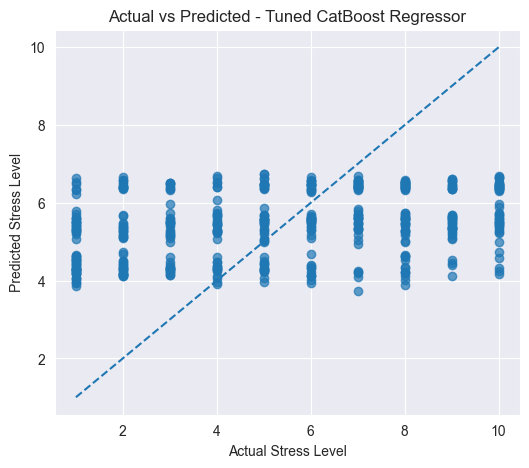

In [29]:
y_pred_tuned_regression = best_tuned_regression_model.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_tuned_regression, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")

plt.title(f"Actual vs Predicted - Tuned {best_tuned_regression_model_name}")
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.show()

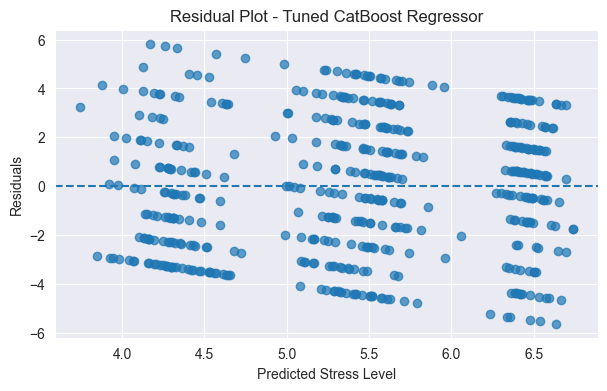

In [30]:
tuned_residuals = y_test - y_pred_tuned_regression

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_tuned_regression, tuned_residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.title(f"Residual Plot - Tuned {best_tuned_regression_model_name}")
plt.xlabel("Predicted Stress Level")
plt.ylabel("Residuals")
plt.show()

## Tuned Regression Visual Evaluation

The tuned CatBoost Regressor slightly improved the regression performance compared to the baseline models, but the overall predictive power remains limited.

The Actual vs Predicted plot shows that the model tends to predict values around the middle of the stress scale. Although the real `Stress_Level` values range from 1 to 10, the predicted values are mostly concentrated between approximately 4 and 6.7.

This means that the model has difficulty predicting very low and very high stress levels. The residual plot also confirms that the prediction errors are spread across the prediction range.

Overall, the tuned model provides a small improvement, but the low R2 score indicates that the available features explain only a limited part of the variation in stress level.

## Learning Curves for the Top 5 Tuned Regression Models

Learning curves are used to analyze how the model performance changes as the training set size increases.

For regression, the learning curves are evaluated using RMSE. A lower RMSE indicates better performance. By comparing training RMSE and validation RMSE, we can identify possible overfitting or underfitting.

In [31]:
from sklearn.model_selection import learning_curve

Learning curve for CatBoost Regressor...


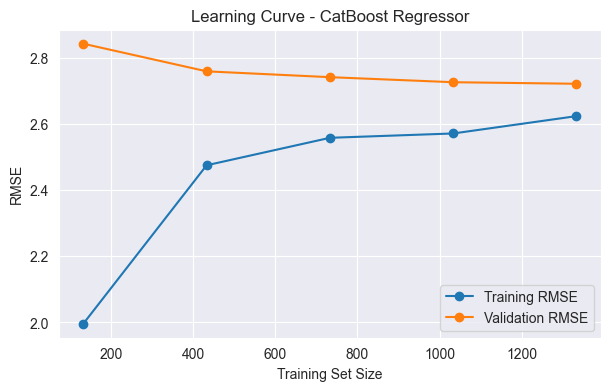

Learning curve for Linear Regression...


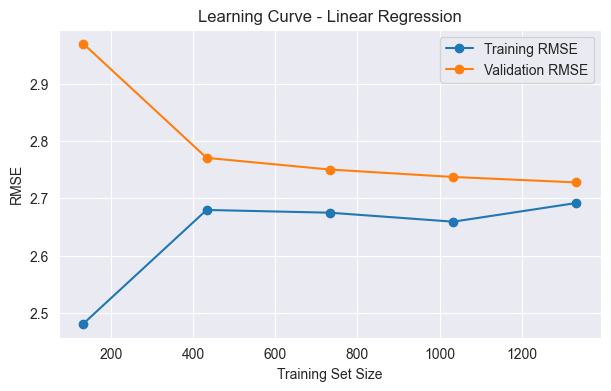

Learning curve for Explainable Boosting Regressor...


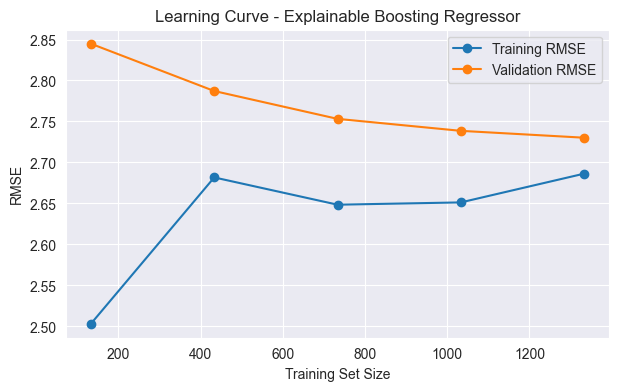

Learning curve for Random Forest Regressor...


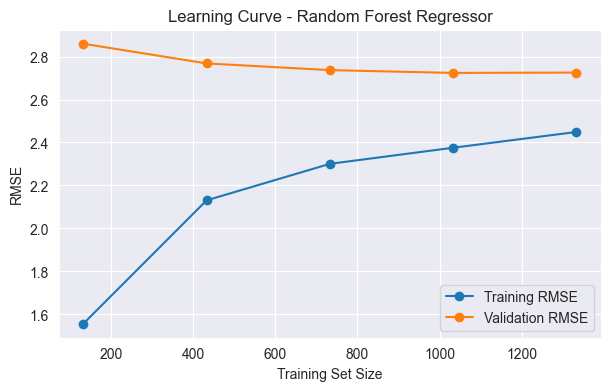

Learning curve for Gaussian Process Regressor...


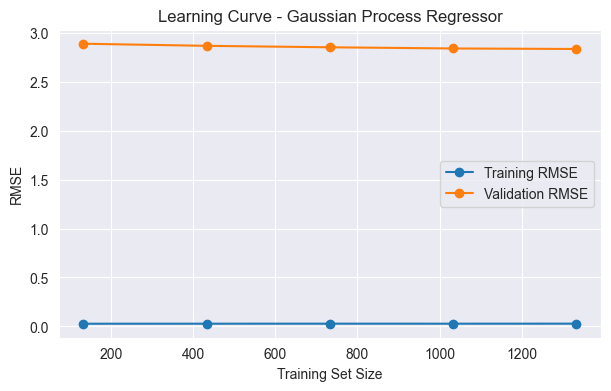

In [32]:
top_5_tuned_regression_model_names = tuned_regression_results_df["Model"].head(5).tolist()

for model_name in top_5_tuned_regression_model_names:
    print(f"Learning curve for {model_name}...")

    model = tuned_regression_models[model_name]

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    train_rmse = -train_scores.mean(axis=1)
    validation_rmse = -validation_scores.mean(axis=1)

    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
    plt.plot(train_sizes, validation_rmse, marker="o", label="Validation RMSE")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

## Regression Learning Curves Interpretation

The regression learning curves compare the training RMSE and validation RMSE for the top five tuned regression models.

For CatBoost Regressor, Linear Regression, and Explainable Boosting Regressor, the training and validation RMSE values become relatively close as the training set size increases. This suggests that these models do not suffer from severe overfitting, but their predictive performance remains limited.

Random Forest Regressor shows a larger gap between training and validation RMSE, which indicates a tendency toward overfitting.

Gaussian Process Regressor shows a very low training RMSE and a much higher validation RMSE. This indicates strong overfitting, meaning that the model fits the training data very closely but does not generalize well to unseen data.

Overall, the learning curves confirm that predicting `Stress_Level` is a difficult regression task with the available features. The main limitation is the moderate predictive signal in the dataset, not only the model choice.

## SHAP Explainability Analysis for the Top 3 Tuned Regression Models

SHAP is used to explain how each feature contributes to the predicted stress level.

In this section, SHAP explanations are generated for the top three tuned regression models:

1. CatBoost Regressor
2. Linear Regression
3. Explainable Boosting Regressor

The analysis includes global explanations, local explanations, and scatter plots for the most influential features.

In [33]:
import shap

shap.initjs()

In [34]:
top_3_tuned_regression_model_names = tuned_regression_results_df["Model"].head(3).tolist()

print("Top 3 tuned regression models:")
print(top_3_tuned_regression_model_names)

Top 3 tuned regression models:
['CatBoost Regressor', 'Linear Regression', 'Explainable Boosting Regressor']


In [35]:
def get_preprocessed_regression_data(pipeline, X_train, X_test):
    fitted_preprocessor = pipeline.named_steps["preprocessor"]

    X_train_transformed = fitted_preprocessor.transform(X_train)
    X_test_transformed = fitted_preprocessor.transform(X_test)

    feature_names = fitted_preprocessor.get_feature_names_out()
    feature_names = [
        name.replace("num__", "").replace("cat__", "")
        for name in feature_names
    ]

    X_train_processed = pd.DataFrame(X_train_transformed, columns=feature_names)
    X_test_processed = pd.DataFrame(X_test_transformed, columns=feature_names)

    return X_train_processed, X_test_processed, feature_names

In [36]:
regression_shap_values_dict = {}
regression_shap_data_dict = {}

for model_name in top_3_tuned_regression_model_names:
    print(f"Computing SHAP values for {model_name}...")

    pipeline = tuned_regression_models[model_name]
    model = pipeline.named_steps["model"]

    X_train_processed, X_test_processed, feature_names = get_preprocessed_regression_data(
        pipeline,
        X_train,
        X_test
    )

    background_data = X_train_processed.sample(
        n=min(80, len(X_train_processed)),
        random_state=42
    )

    explain_data = X_test_processed.sample(
        n=min(50, len(X_test_processed)),
        random_state=42
    )

    masker = shap.maskers.Independent(background_data)

    explainer = shap.PermutationExplainer(
        model.predict,
        masker,
        feature_names=feature_names
    )

    shap_values = explainer(
        explain_data,
        max_evals=2 * explain_data.shape[1] + 1
    )

    regression_shap_values_dict[model_name] = shap_values
    regression_shap_data_dict[model_name] = explain_data

print("Regression SHAP computation finished.")

Computing SHAP values for CatBoost Regressor...


PermutationExplainer explainer: 51it [00:11,  4.42it/s]                         


Computing SHAP values for Linear Regression...
Computing SHAP values for Explainable Boosting Regressor...
Regression SHAP computation finished.


SHAP Summary Plot - CatBoost Regressor


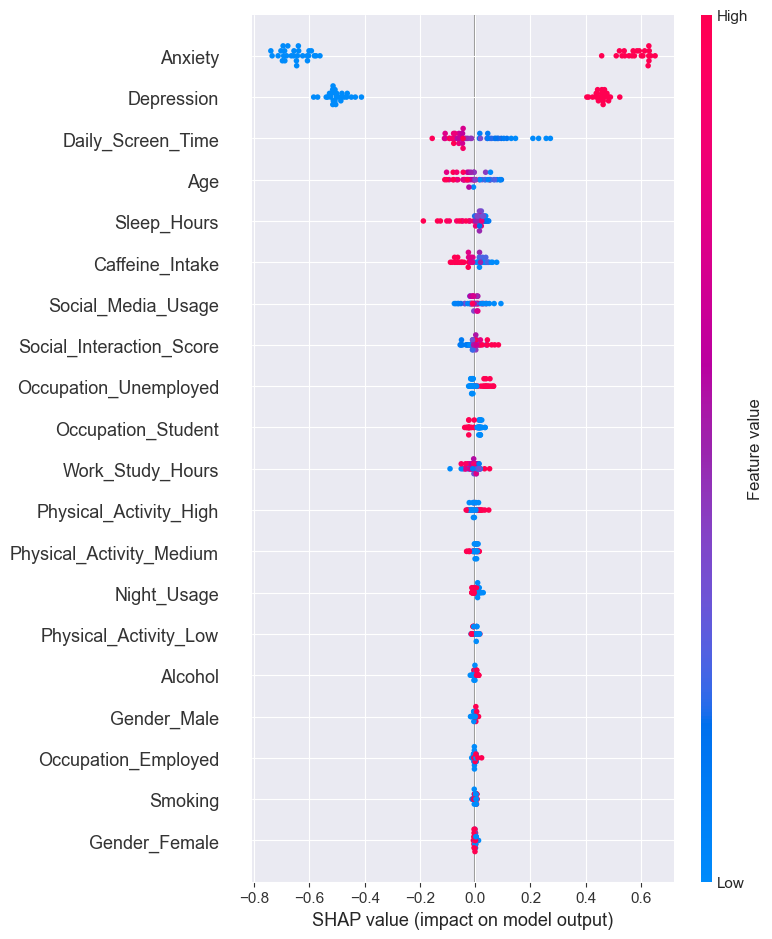

SHAP Summary Plot - Linear Regression


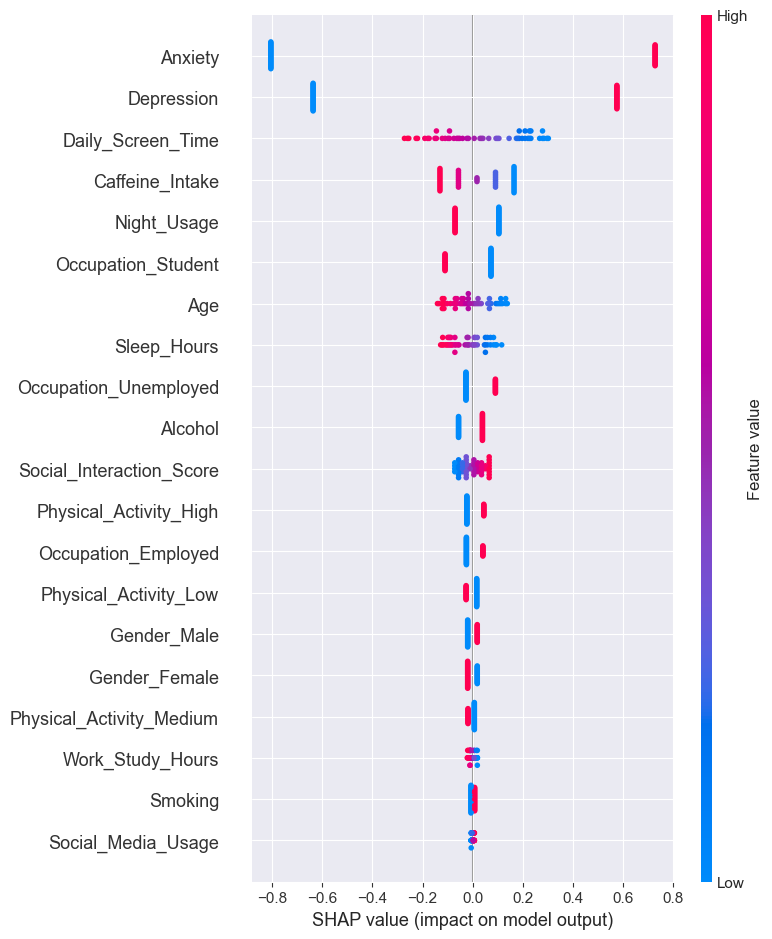

SHAP Summary Plot - Explainable Boosting Regressor


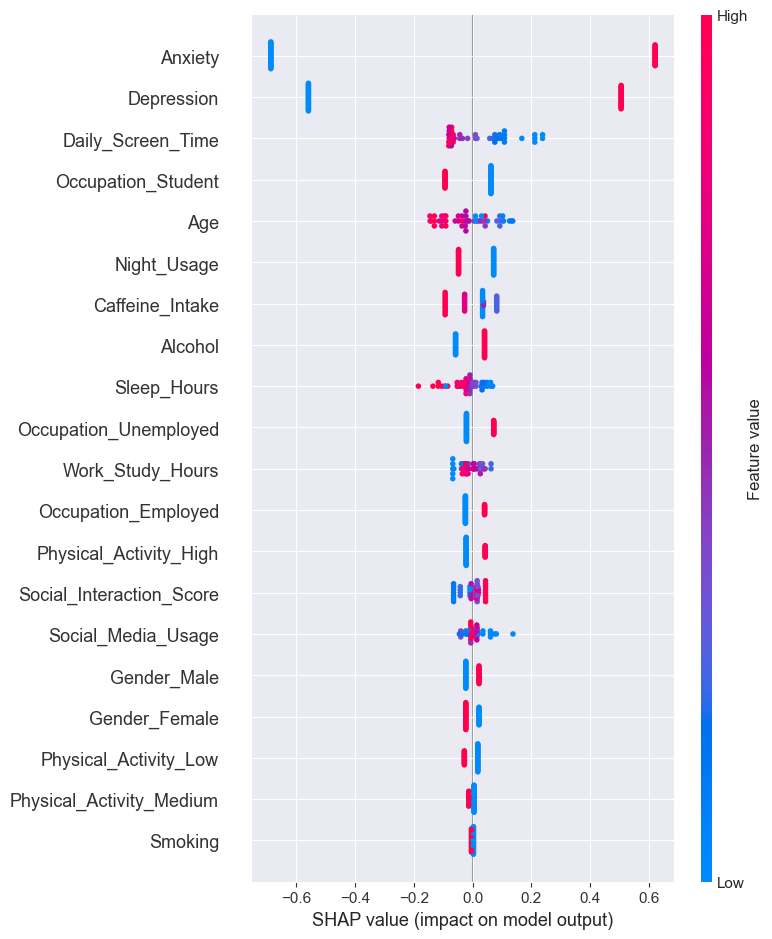

In [37]:
for model_name in top_3_tuned_regression_model_names:
    print(f"SHAP Summary Plot - {model_name}")

    shap.summary_plot(
        regression_shap_values_dict[model_name].values,
        regression_shap_data_dict[model_name],
        feature_names=regression_shap_values_dict[model_name].feature_names
    )

SHAP Bar Plot - CatBoost Regressor


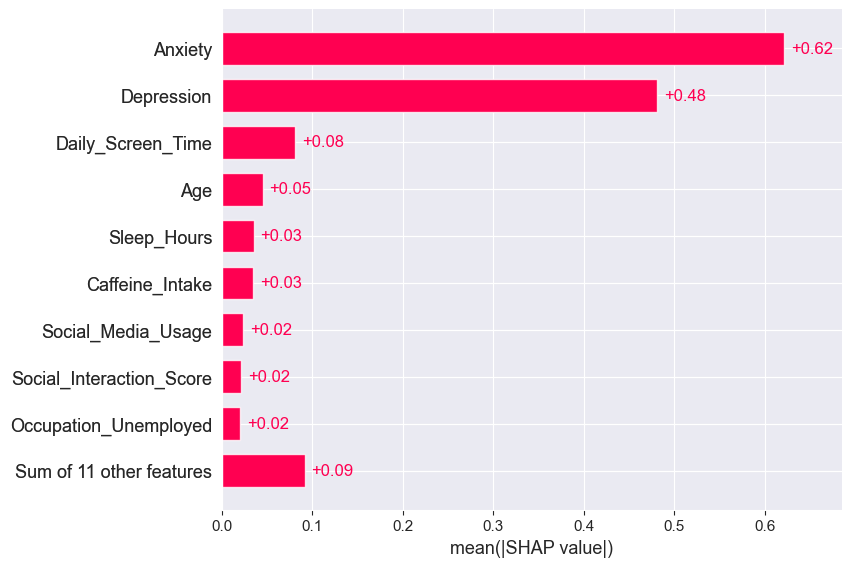

SHAP Bar Plot - Linear Regression


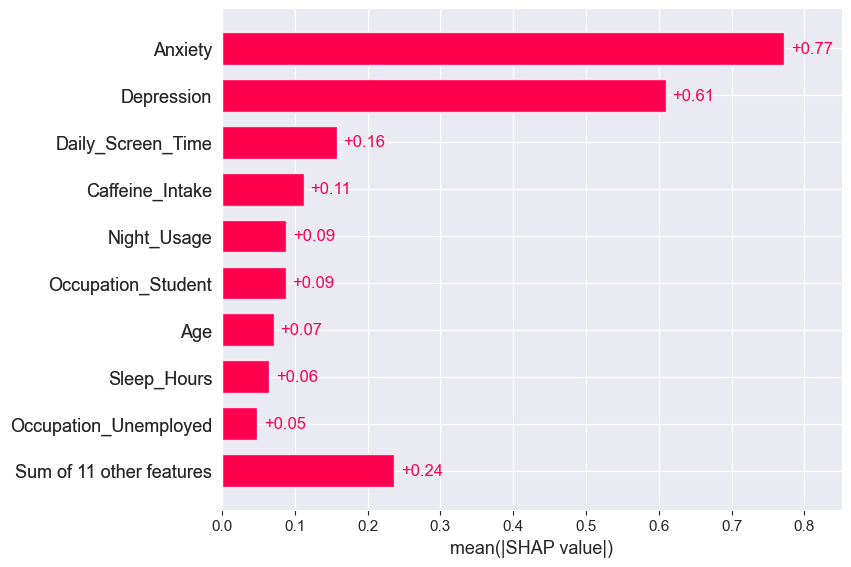

SHAP Bar Plot - Explainable Boosting Regressor


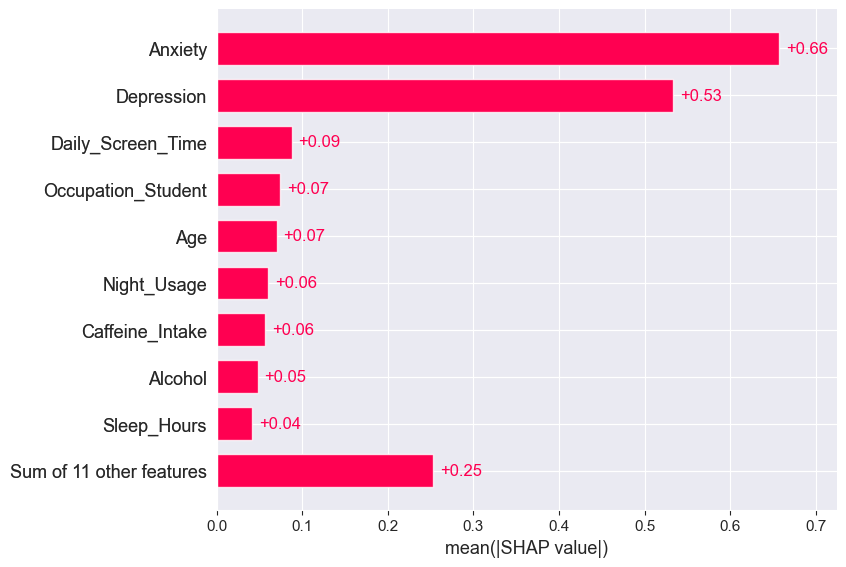

In [38]:
for model_name in top_3_tuned_regression_model_names:
    print(f"SHAP Bar Plot - {model_name}")

    shap.plots.bar(
        regression_shap_values_dict[model_name],
        max_display=10
    )

SHAP Waterfall Plot - CatBoost Regressor


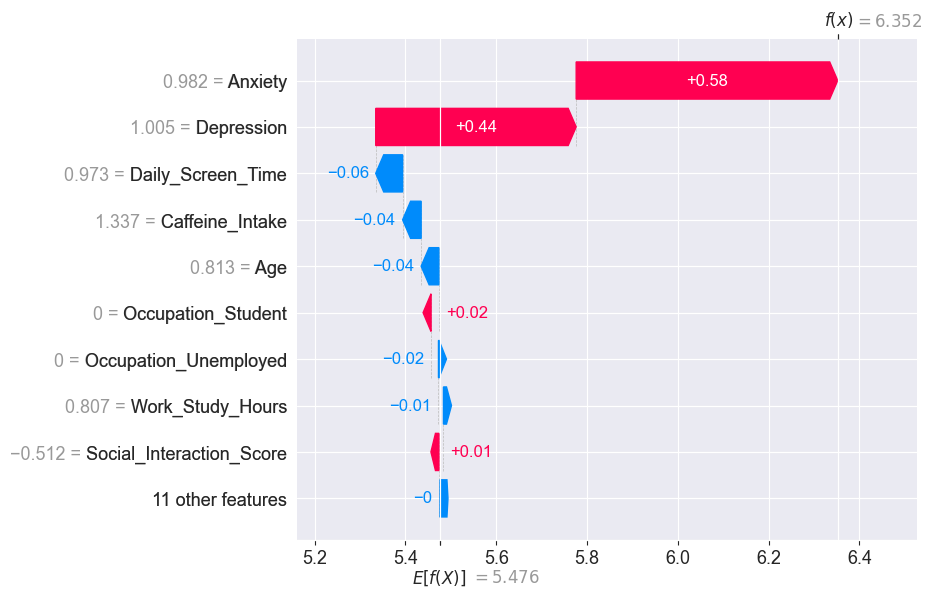

SHAP Waterfall Plot - Linear Regression


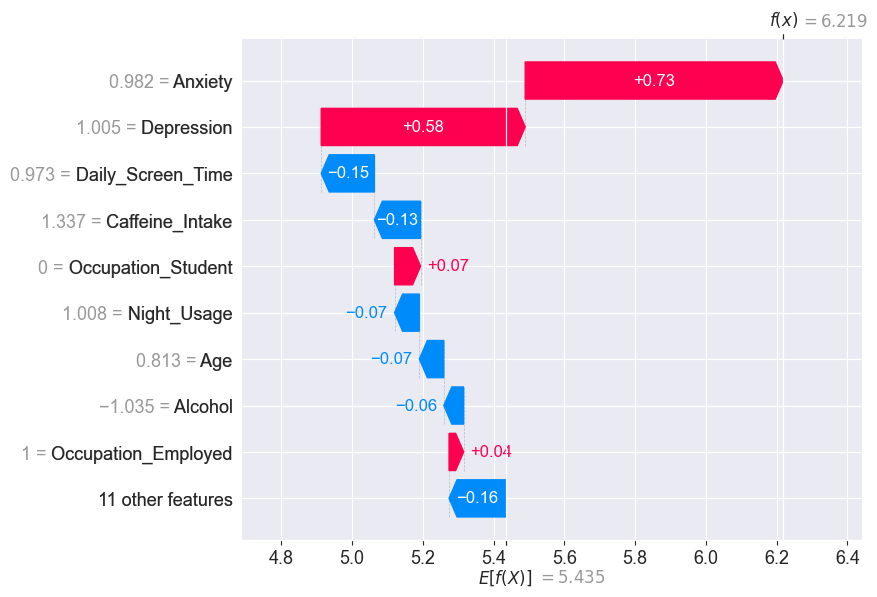

SHAP Waterfall Plot - Explainable Boosting Regressor


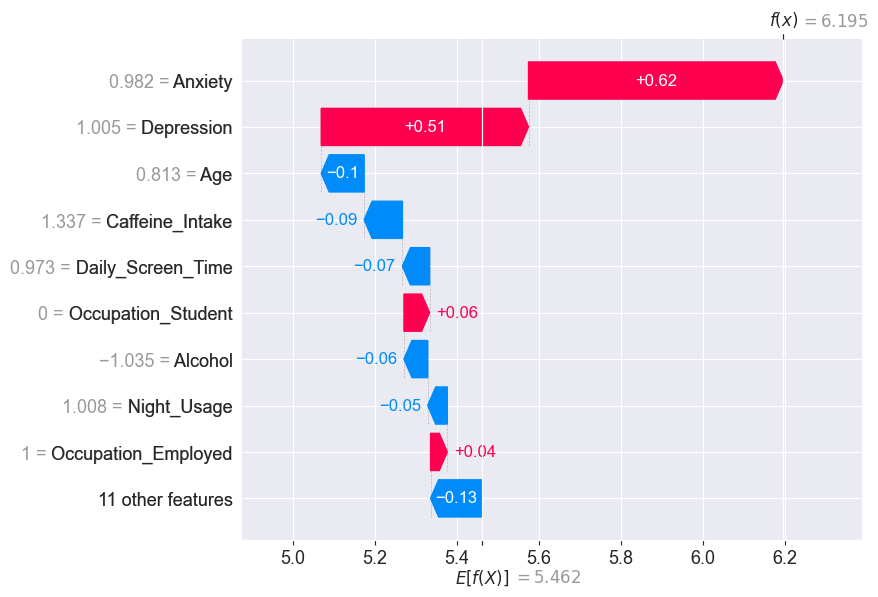

In [39]:
for model_name in top_3_tuned_regression_model_names:
    print(f"SHAP Waterfall Plot - {model_name}")

    shap.plots.waterfall(
        regression_shap_values_dict[model_name][0],
        max_display=10
    )

SHAP Force Plot - CatBoost Regressor


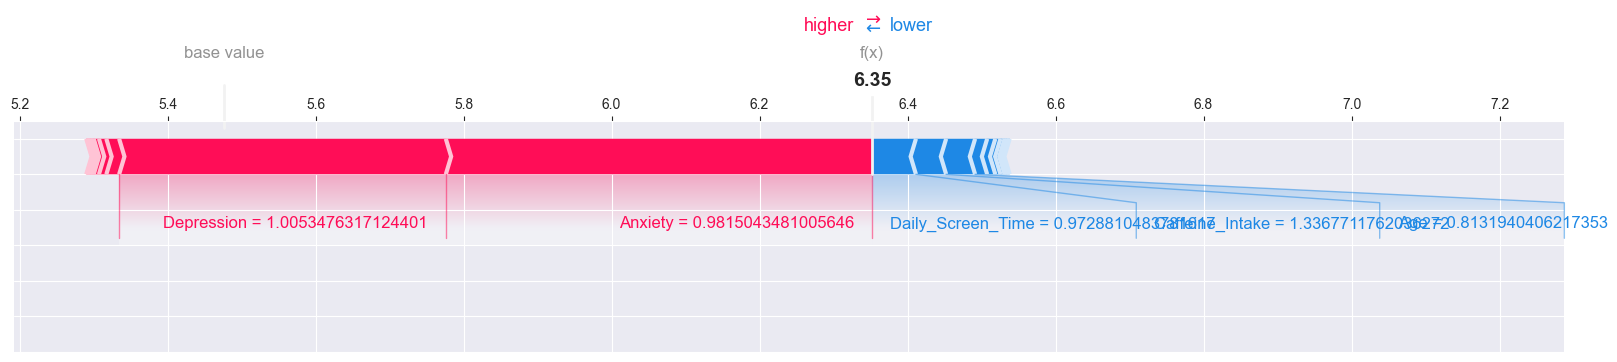

SHAP Force Plot - Linear Regression


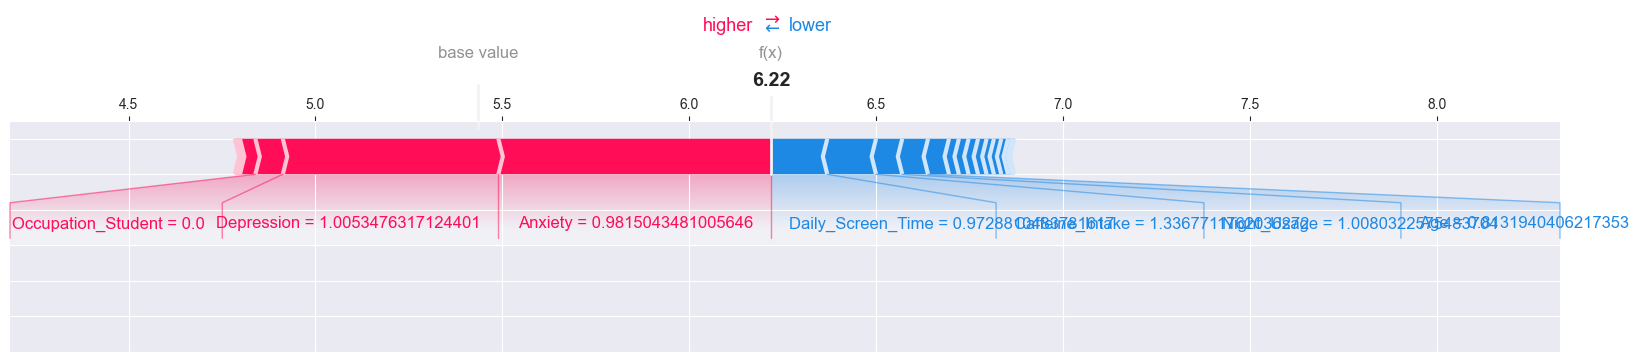

SHAP Force Plot - Explainable Boosting Regressor


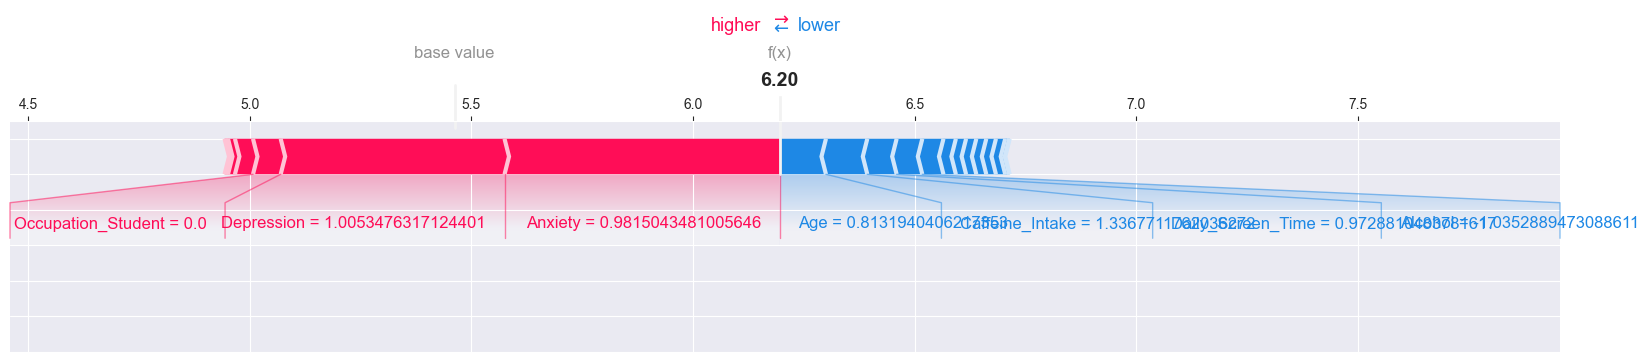

In [40]:
for model_name in top_3_tuned_regression_model_names:
    print(f"SHAP Force Plot - {model_name}")

    shap.force_plot(
        regression_shap_values_dict[model_name].base_values[0],
        regression_shap_values_dict[model_name].values[0],
        regression_shap_data_dict[model_name].iloc[0],
        matplotlib=True,
        show=True
    )

SHAP Scatter Plots - CatBoost Regressor
Top 3 SHAP features: ['Anxiety', 'Depression', 'Daily_Screen_Time']


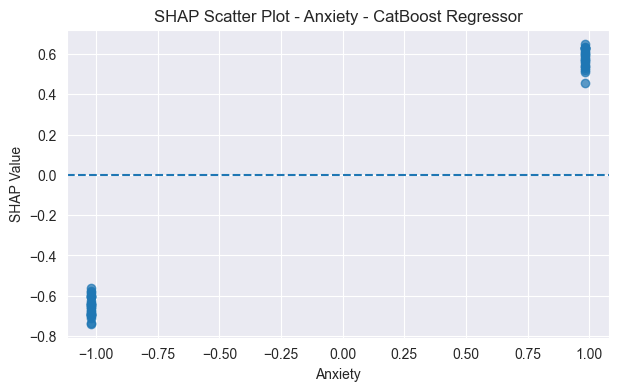

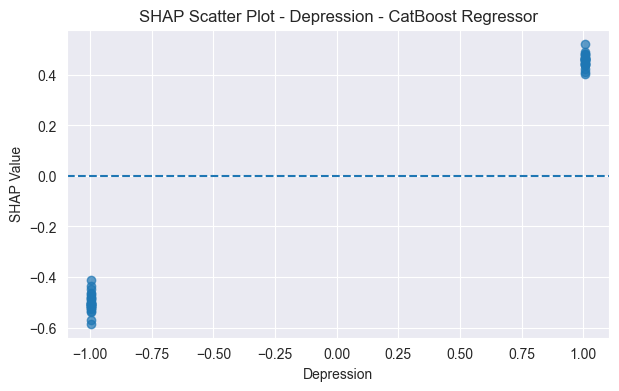

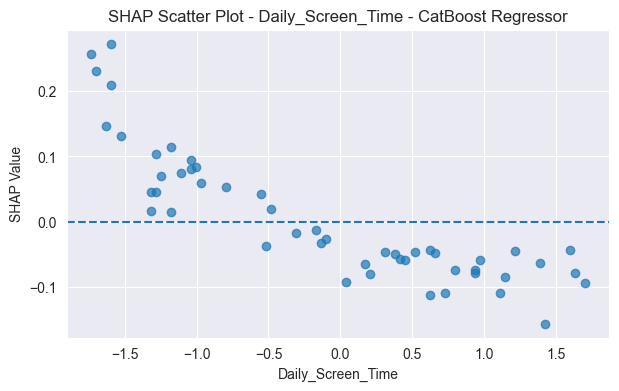

SHAP Scatter Plots - Linear Regression
Top 3 SHAP features: ['Anxiety', 'Depression', 'Daily_Screen_Time']


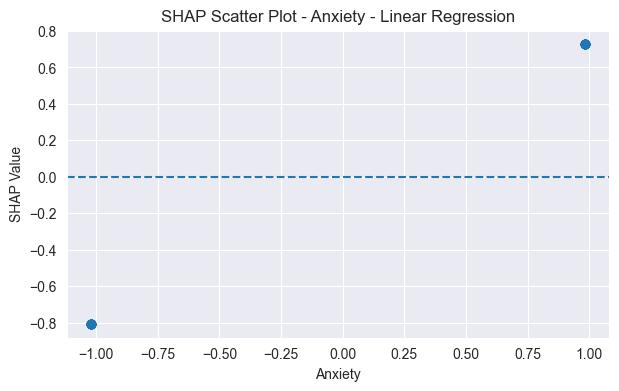

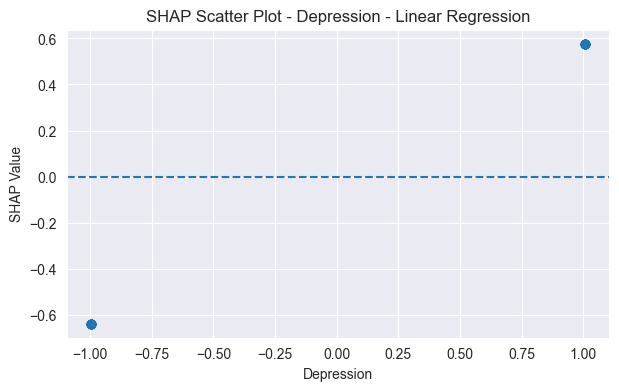

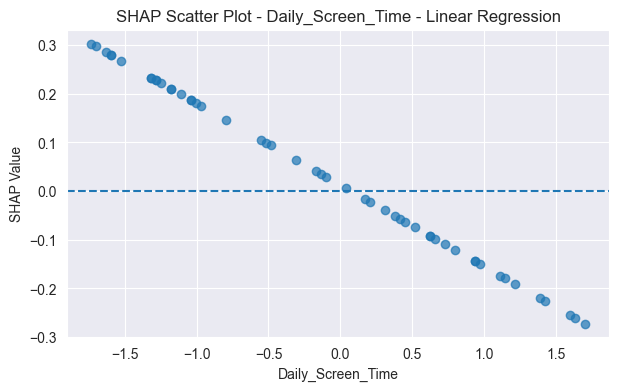

SHAP Scatter Plots - Explainable Boosting Regressor
Top 3 SHAP features: ['Anxiety', 'Depression', 'Daily_Screen_Time']


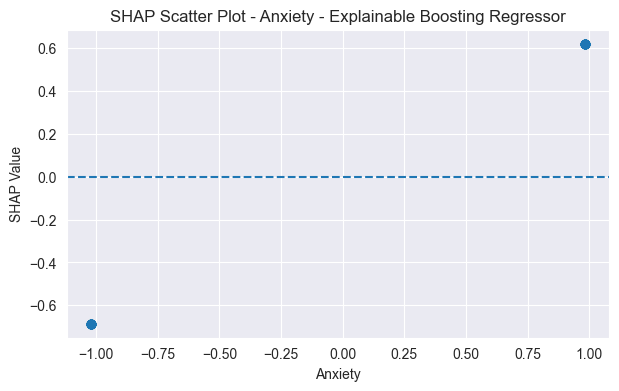

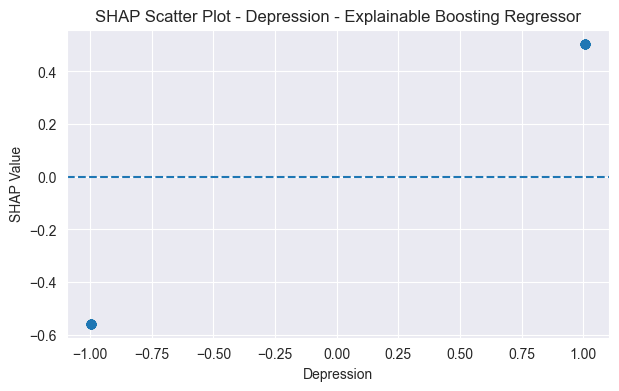

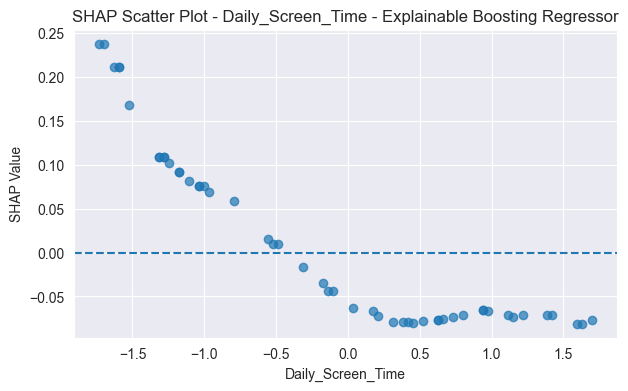

In [41]:
for model_name in top_3_tuned_regression_model_names:
    print(f"SHAP Scatter Plots - {model_name}")

    shap_values = regression_shap_values_dict[model_name]
    explain_data = regression_shap_data_dict[model_name]

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    top_features = pd.Series(
        mean_abs_shap,
        index=shap_values.feature_names
    ).sort_values(ascending=False).head(3).index.tolist()

    print("Top 3 SHAP features:", top_features)

    for feature in top_features:
        feature_index = list(shap_values.feature_names).index(feature)

        plt.figure(figsize=(7, 4))
        plt.scatter(
            explain_data[feature],
            shap_values.values[:, feature_index],
            alpha=0.7
        )
        plt.axhline(0, linestyle="--")
        plt.title(f"SHAP Scatter Plot - {feature} - {model_name}")
        plt.xlabel(feature)
        plt.ylabel("SHAP Value")
        plt.show()

## Regression SHAP Interpretation

The SHAP analysis was performed for the top three tuned regression models.

For the regression task, the most important features identified by SHAP were `Anxiety`, `Depression`, and `Daily_Screen_Time`.

Higher values of `Anxiety` tend to increase the predicted stress level. This can be observed in the SHAP scatter plots, where higher anxiety values have positive SHAP values, pushing the prediction upward.

A similar pattern appears for `Depression`. When depression is present or higher, the SHAP values are positive, meaning that this feature increases the predicted stress level.

`Daily_Screen_Time` also appears as an important feature. In this model, lower standardized values of daily screen time tend to have positive SHAP values, while higher standardized values tend to have negative SHAP values. This indicates that the relationship learned by the model is not purely intuitive and may reflect the synthetic structure of the dataset.

Overall, SHAP shows that the regression models rely mostly on mental health-related indicators, especially anxiety and depression, when predicting stress level.

In [44]:
import joblib

REGRESSION_MODEL_PATH = PROJECT_ROOT / "models" / "best_regression_model.pkl"

joblib.dump(best_tuned_regression_model, REGRESSION_MODEL_PATH)

print("Saved best regression model to:", REGRESSION_MODEL_PATH)

Saved best regression model to: D:\faculta\an3\sem2\ProiectMl\models\best_regression_model.pkl
